# What is Spark SQL?

Spark SQL is a module in Apache Spark that enables users to work with structured data using SQL queries, data frames, and datasets. With Spark SQL, users can perform complex data analysis tasks by writing SQL queries or DataFrame/Dataset API code in Java, Scala, Python, or R. It provides a unified interface for handling data from various data sources, including Hive tables, Parquet, ORC, JSON, and JDBC data sources. Additionally, Spark SQL offers high performance by optimizing the execution of SQL queries and leveraging the distributed computing capabilities of Spark, making it a popular tool for big data processing and analytics.

Here are some key features of Spark SQL:

1. SQL support: Spark SQL provides a standard SQL interface for querying structured data stored in various data sources.

2. DataFrame/Dataset API: It offers a high-level API for working with structured data in a programmatic way using DataFrame and Dataset abstractions.

3. Integration with other Spark components: Spark SQL integrates with other Spark components like Spark Streaming, MLlib, and GraphX, making it easier to build end-to-end data pipelines.

4. Support for various data sources: Spark SQL supports various data sources such as Hive tables, Parquet, ORC, JSON, and JDBC data sources.

5. Schema inference: It can automatically infer the schema of structured data from the data itself, making it easier to work with unstructured data.

6. SQL optimizations: Spark SQL optimizes SQL queries by leveraging the underlying Spark engine's distributed computing capabilities, providing high-performance processing for big data analytics.

7. Window functions: Spark SQL supports window functions, which are a powerful tool for performing complex analytics tasks over ordered data partitions.







### Start Spark Session

In [ ]:
# Suppress native-hadoop warning
!sed -i '$a\# Add the line for suppressing the NativeCodeLoader warning \nlog4j.logger.org.apache.hadoop.util.NativeCodeLoader=ERROR,console' /$HADOOP_HOME/etc/hadoop/log4j.properties
import os; os.close(os.dup2(os.open(os.devnull, os.O_WRONLY), 2))

In [ ]:
!hadoop fs -copyFromLocal courses.csv  /courses.csv
!hadoop fs -copyFromLocal professors.csv  /professors.csv

In [ ]:
import pyspark
from pyspark.sql import SparkSession

conf = pyspark.SparkConf().setAll([('spark.master', 'local[4]'),
                                   ('spark.app.name', 'Spark SQL')])
spark = SparkSession.builder.config(conf=conf).getOrCreate()

### Load the required dataframes from HDFS

In [ ]:
courses = spark.read.format("csv").option("header","true").load('hdfs:///courses.csv')
professors = spark.read.format("csv").option("header","true").load('hdfs:///professors.csv')

In [ ]:
courses.show()

In [ ]:
professors.show(truncate=False)

### INNER JOIN

In [ ]:
courses.join(professors,"prof_id",how="inner").select("code","course_name","prof_id","prof_name").show()

### CROSS JOIN

In [ ]:
courses.join(professors,how="cross").show()

### LEFT OUTER JOIN

In [ ]:
courses.join(professors,"prof_id",how="left_outer").show()

### LEFT SEMI JOIN

In [ ]:
courses.join(professors,"prof_id",how="left_semi").show()

### LEFT ANTI JOIN

In [ ]:
courses.join(professors,"prof_id",how="left_anti").show()

### BUT HOW DOES SPARK IMPLEMENT THESE JOINS ALGORITHMICALLY?

The different types of joins that can be performed in Spark based on their algorithms:

1. **Broadcast Hash Join**: This type of join is used when one table is significantly smaller than the other table. The smaller table is broadcasted to all the worker nodes and then joined with the larger table using hash join.

2. **Sort Merge Join**: This type of join is used when both the tables are large and can't be broadcasted to the worker nodes. Both tables are sorted on the join key and then joined using merge join.

3. **Shuffle Hash Join**: This type of join is used when both tables are large and can't be broadcasted to the worker nodes, but one or both tables are not sorted on the join key. The data is partitioned, shuffled and grouped based on the join key and then joined using hash join.

4. **Cartesian Join**: This type of join is used when there is no join condition specified, and it returns all the possible combinations of rows from both tables. Cartesian join can be very expensive in terms of computational resources and should be used with caution.

In summary, the choice of join algorithm in Spark depends on the size of the tables, whether the tables can be broadcasted or not, and whether the join key is sorted or not.

### CHECKOUT SPARK UI!

Spark UI is a web-based user interface that provides detailed information about Spark applications and their execution. It allows developers and operators to monitor and debug Spark applications in real-time.

Spark UI provides a dashboard with multiple tabs that contain information about different aspects of a Spark application, such as jobs, stages, tasks, and storage. 

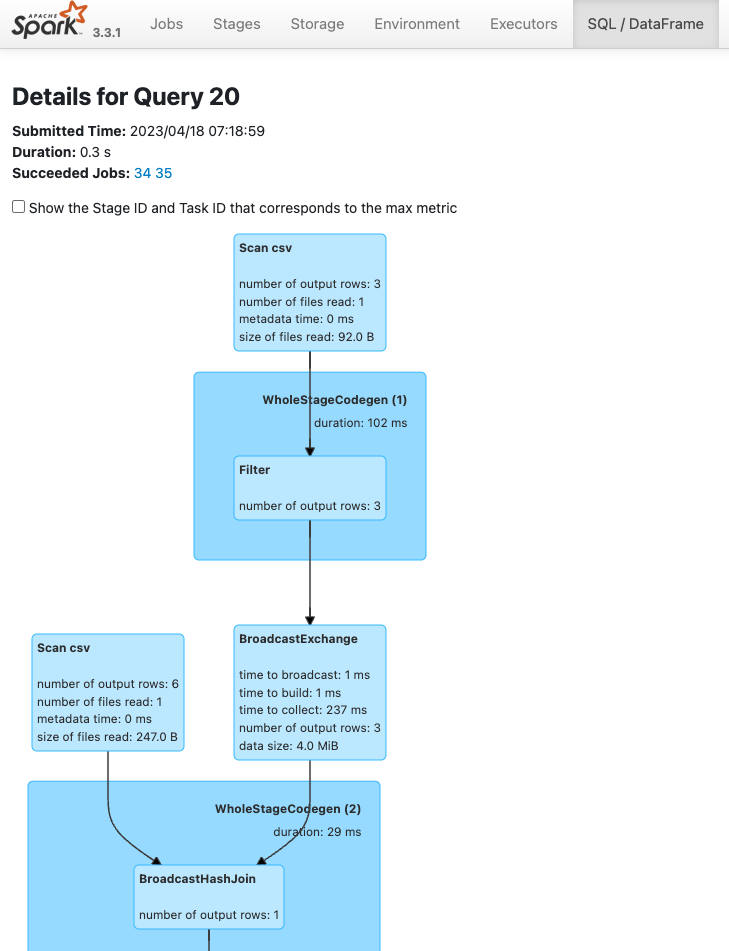

### FEW MORE IMPORTANT SQL APIs

In [ ]:
!hadoop fs -copyFromLocal orders.csv  /orders.csv

In [ ]:
from pyspark.sql.types import *

schema = StructType([
    StructField("order_item_id", IntegerType(), True),
    StructField("price", DoubleType(), True),
    StructField("freight_value", DoubleType(), True)
])

orders = spark.read.schema(schema) \
    .option("header", "true") \
    .csv("hdfs:///orders.csv")

orders.show(10)

#### WINDOW API

Window functions operate on a group of rows, referred to as a window, and calculate a return value for each row based on the group of rows. Window functions are useful for processing tasks such as calculating a moving average, computing a cumulative statistic, or accessing the value of rows given the relative position of the current row.

[Spark Window Documentation](https://spark.apache.org/docs/latest/sql-ref-syntax-qry-select-window.html)

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc
from pyspark.sql.functions import rank,dense_rank
from pyspark.sql.functions import avg,col

windowPartition = Window.partitionBy("order_item_id").orderBy("price")
orders.withColumn("row_number",row_number().over(windowPartition)).show()

In [ ]:
windowPartition = Window.partitionBy("order_item_id").orderBy(desc("price"))
orders.withColumn("dense_rank",dense_rank().over(windowPartition)).show()

In [ ]:
windowPartitionAvg = Window.partitionBy("order_item_id")
orders.withColumn("Avg Price Per Item Id",avg(col("price")).over(windowPartitionAvg)).orderBy(desc("order_item_id")).show(50)

### Write Dataframe to File

In [ ]:
orders.repartition(1).write.save('hdfs:///orders', mode="overwrite")

In [ ]:
!hdfs dfs -ls /orders